In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('better_data_1.xlsx')
models = joblib.load('model_2.pkl')
xgb_model = models['xgb']
lgb_model = models['lgb']
meta_model = models['meta']
scaler = models['scaler']

In [3]:
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
df['lag1'] = df['today_peak_load'].shift(1)
df['lag7'] = df['today_peak_load'].shift(7)
df['roll3'] = df['today_peak_load'].rolling(3).mean()
df['roll7'] = df['today_peak_load'].rolling(7).mean()
df = df.dropna().reset_index(drop=True)

In [4]:
FEATURE_COLS = [
    'BRPL', 'TPDDL', 'BYPL', 'NDMC',
    'today_peak_load', 'public_holiday',
    'temperature', 'precipitation', 'wind_speed',
    'dow', 'is_weekend','lag1',
    'lag7', 'roll3', 'roll7'
]
TARGET_COL = 'tomorrow peak load'

In [5]:
err_xgb = []
err_lgb = []
err_stack = []
results = []
skipped = 0

In [6]:
# print(f"{'Index':<5} {'Predicted':<12} {'Actual':<10} {'% Error':<10}")
# print("-" * 40)

for i in range(len(df)):
    row = df.iloc[i]
    features = row[FEATURE_COLS]
    actual = row[TARGET_COL]

    if pd.isna(actual) or features.isna().any() or actual == 0:
        skipped += 1
        continue

    features_df = pd.DataFrame([features.values], columns=FEATURE_COLS)
    features_scaled = scaler.transform(features_df)

    pred_xgb = xgb_model.predict(features_scaled)[0]
    pred_lgb = lgb_model.predict(features_scaled)[0]

    stack_in = np.array([[pred_xgb, pred_lgb]])
    pred_stack = meta_model.predict(stack_in)[0]

    ape_xgb = abs((actual - pred_xgb) * 100 / actual)
    ape_lgb = abs((actual - pred_lgb) * 100 / actual)
    ape_stack = abs((actual - pred_stack) * 100 / actual)

    err_xgb.append(ape_xgb)
    err_lgb.append(ape_lgb)
    err_stack.append(ape_stack)

    results.append((i, pred_xgb, pred_lgb, pred_stack, actual, ape_xgb, ape_lgb, ape_stack))

print("Number of skipped rows:", skipped)

Number of skipped rows: 0


In [17]:
print(f"mean ape (XGBoost): {np.mean(err_xgb):.2f}%")
print(f"mean ape (LightGBM): {np.mean(err_lgb):.2f}%")
print(f"mean ape (Stacked): {np.mean(err_stack):.2f}%")

mean ape (XGBoost): 2.66%
mean ape (LightGBM): 3.35%
mean ape (Stacked): 6.16%


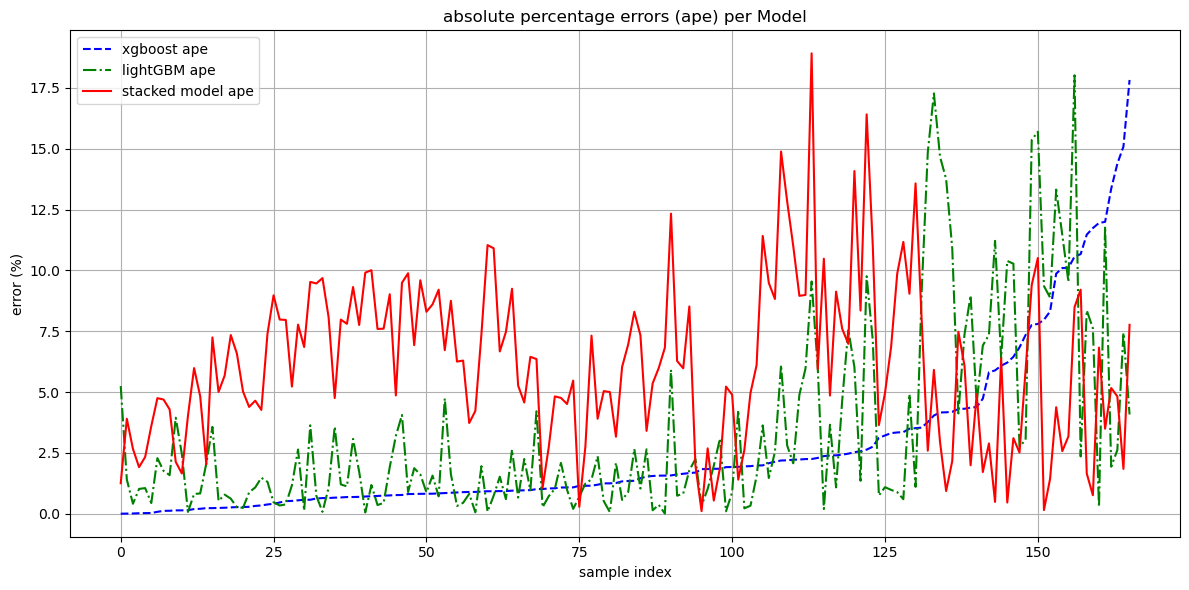

In [29]:
#Unsorted error plot
plt.figure(figsize=(12, 6))
plt.plot(err_xgb, label='xgboost ape', color='blue', linestyle='--')
plt.plot(err_lgb, label='lightGBM ape', color='green', linestyle='-.')
plt.plot(err_stack, label='stacked model ape', color='red', linestyle='-')
plt.title("absolute percentage errors (ape) per Model")
plt.xlabel("sample index")
plt.ylabel("error (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# actual_loads = [r[4] for r in results]  
# ape_stack = [r[7] for r in results]     

# plt.figure(figsize=(10, 6))
# plt.scatter(actual_loads, ape_stack, color='red', alpha=0.6)
# plt.title("APE (Stacked Model) vs Actual Load")
# plt.xlabel("Actual Load")
# plt.ylabel("APE (%)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [21]:
err_xgb.sort()

sorted_results = sorted(results, key=lambda x: x[7])

# print("\nSorted Errors (by xgb % Error):")
# print(f"{'Index':<5} {'Pred_XGB':<12} {'Pred_LGB':<12} {'Pred_Stack':<12} {'Actual':<10} {'APE_XGB':<10} {'APE_LGB':<10} {'APE_Stack':<10}")
# print("-" * 90)

# for i, pred_xgb, pred_lgb, pred_stack, actual, ape_xgb, ape_lgb, ape_stack in sorted_results:
#     print(f"{i:<5} {pred_xgb:<12.2f} {pred_lgb:<12.2f} {pred_stack:<12.2f} {actual:<10.2f} {ape_xgb:<10.2f} {ape_lgb:<10.2f} {ape_stack:<10.2f}")

In [28]:
filtered_errors = [e for e in err_stack if np.isfinite(e)]

if filtered_errors:
    avg_error = np.mean(filtered_errors)
    print("\nAverage Error:", round(avg_error, 2))
else:
    print("No valid error values to compute average and max.")


Average Error: 6.16


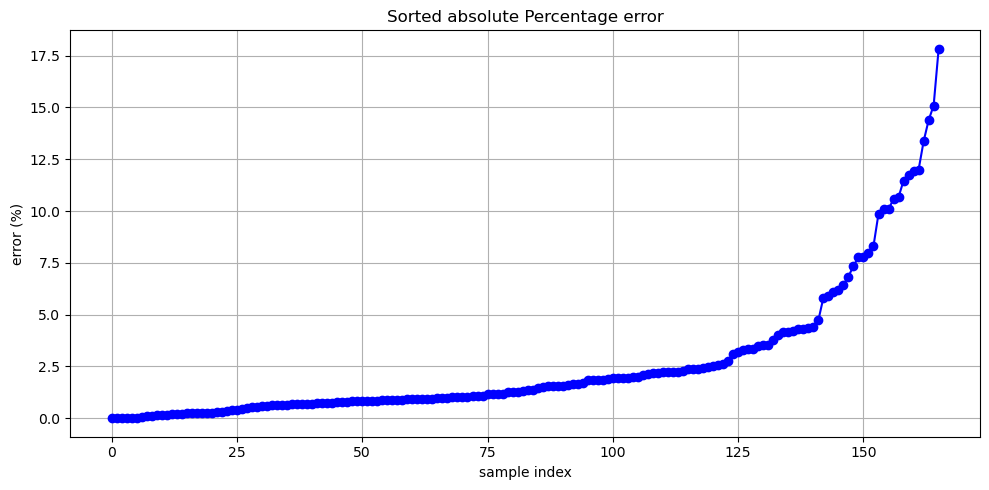

In [30]:
# Sorted error plot
plt.figure(figsize=(10, 5))
plt.plot(err_xgb, color='blue', marker='o', linestyle='-')
plt.title("Sorted absolute Percentage error")
plt.xlabel("sample index")
plt.ylabel("error (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
predicted_vals = [r[1] for r in results]
actual_vals = [r[2] for r in results]

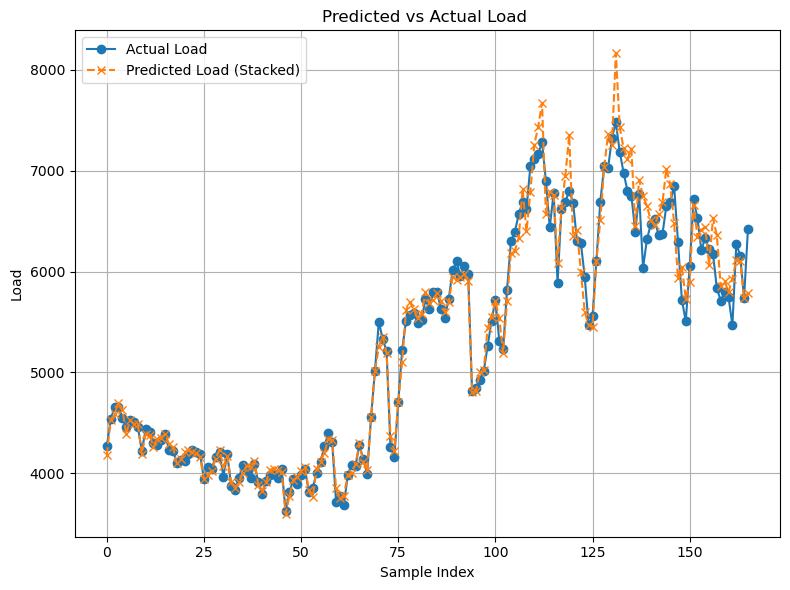

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(actual_vals, label='Actual Load', marker='o', linestyle='-')
plt.plot(predicted_vals, label='Predicted Load (Stacked)', marker='x', linestyle='--')
plt.title("Predicted vs Actual Load ")
plt.xlabel("Sample Index")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
print('Max Load predicted for next day:', pred_xgb)

Max Load predicted for next day: 6571.5796


In [34]:
df.iloc[-1]['today_peak_load']

np.int64(6197)